# ResNet classifier

## Importations

In [14]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.effects

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support
from collections import Counter

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, regularizers
from tensorflow.keras.utils import to_categorical

from classification.datasets import Dataset
from classification.utils.audio_student import AudioUtil, Feature_vector_DS
from classification.utils.plots import show_confusion_matrix

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")
np.random.seed(42)
tf.random.set_seed(42)

TensorFlow version: 2.20.0
GPU Available: []


## Config

In [15]:
class Config:
    """
    Centralized configuration – PC training, no embedded size constraint.

    Paramètres audio
    ────────────────
    SAMPLE_RATE   : fréquence d'échantillonnage. 22050 Hz = standard qualité.
                    Capture les fréquences jusqu'à 11025 Hz (Nyquist).
                    Si tu baisses à 11025, tu coupes les hautes fréquences
                    mais tu divises par 2 la taille des spectrogrammes.

    N_MEL         : nombre de bandes de fréquence mel dans le spectrogramme.
                    20 = input 20xT (pauvre en information)
                    64 = input 64xT (3x plus riche, recommandé)
                    128 = encore plus riche, mais plus lent

    N_FFT         : taille de la fenêtre FFT.
                    512  = 23ms par frame à 22050Hz, résolution temporelle fine
                    1024 = 46ms par frame, meilleure résolution fréquentielle
                    2048 = 93ms par frame, très bonne résolution fréq.
                    Compromis : 1024 est le standard pour sons environnementaux

    HOP_LENGTH    : pas entre deux frames FFT successives.
                    Plus petit = plus de frames (plus de données, plus lent)
                    Plus grand = moins de frames
                    Règle : N_FFT // 4 est un bon défaut

    DURATION_MS   : durée de la fenêtre d'analyse en ms.
                    Doit être > durée du son le plus court de tes classes.
                    Gunshot : ~200ms. Fire : continu. 1000ms est un bon compromis.

    Paramètres d'entraînement
    ─────────────────────────
    BATCH_SIZE    : exemples traités ensemble avant une mise à jour des poids.
                    32–64 : bruité mais bonne généralisation
                    128–256 : stable, converge vite
                    Avec petit dataset → 32 ou 64

    LEARNING_RATE : pas d'ajustement des poids. Avec Adam :
                    1e-3 = standard, peut sauter par-dessus les optima
                    5e-4 = plus conservateur, souvent meilleur avec petit LR decay
                    1e-4 = très lent mais précis
                    On utilise cosine decay donc LR descend automatiquement.

    DROPOUT_RATE  : fraction des neurones éteints pendant l'entraînement.
                    0.3 = peu de régularisation
                    0.5 = fort, bien pour petit dataset
                    0.6+ = risque d'underfitting

    LABEL_SMOOTHING : "ramollit" les labels one-hot.
                    0.0 = [0, 0, 1, 0] (dur, le modèle est trop sûr de lui)
                    0.1 = [0.025, 0.025, 0.925, 0.025] (plus humble)
                    Valeurs typiques : 0.05–0.15

    MIXUP_ALPHA   : force du mixup. 0 = désactivé.
                    0.2–0.4 = léger mélange, recommandé pour petit dataset
                    Plus grand → exemples plus "hybrides", risque de confusion

    TTA_STEPS     : nombre de versions augmentées à l'inférence (Test-Time Aug).
                    1 = pas de TTA
                    5 = bon équilibre qualité/vitesse
                    10 = +marginal, 2 fois plus lent
    """

    # ── Audio ─────────────────────────────────────────────────
    SAMPLE_RATE  = 22050   # Hz
    N_MEL        = 64      # bandes mel  (était 20, 3 fois plus riche)
    N_FFT        = 1024    # taille FFT  (était 512)
    HOP_LENGTH   = 256     # pas FFT     (N_FFT // 4)
    DURATION_MS  = 1000    # ms

    # ── Augmentation flags ────────────────────────────────────
    AUG_TIME_SHIFT   = True
    AUG_PITCH_SHIFT  = True
    AUG_TIME_STRETCH = True
    AUG_NOISE        = True
    AUG_SPEC_MASKING = True

    # ── Augmentation params ───────────────────────────────────
    PITCH_SHIFT_RANGE  = (-3, 3)    # +/- 3 demi-tons (plus large qu'avant)
    TIME_STRETCH_RANGE = (0.85, 1.15)
    NOISE_SIGMA        = 0.04

    # ── Architecture ──────────────────────────────────────────
    DROPOUT_RATE    = 0.5
    L2_REG          = 1e-4   # régularisation L2 sur les poids des Conv
    LABEL_SMOOTHING = 0.1    # lissage des labels
    MIXUP_ALPHA     = 0.3    # force du mixup (0 = désactivé)

    # ── Training ──────────────────────────────────────────────
    BATCH_SIZE    = 32
    EPOCHS        = 300
    LEARNING_RATE = 5e-4

    # ── Callbacks ─────────────────────────────────────────────
    EARLY_STOPPING_PATIENCE = 60
    WARMUP_EPOCHS           = 10   # epochs sans LR decay au départ

    # ── TTA ───────────────────────────────────────────────────
    TTA_STEPS = 5   # nombre de passes augmentées à l'inférence

    # ── Paths ─────────────────────────────────────────────────
    MODEL_DIR = "./data/models/models_resnet/"

    # ── Données réelles ───────────────────────────────────────
    TEST_ON_ACQUIRED_DATA = True
    USE_REAL_VAL          = True
    USE_EXTRA_TRAIN_DATA  = True
    ACQUIRED_DATA         = "../mcu/hands_on_audio_acquisition/audio_files"
    EXTRA_TRAIN_DIR       = "../mcu/hands_on_audio_acquisition/audio_files"
    EXTRA_AUG_PASSES      = 40

    # ── Decision ──────────────────────────────────────────────
    CONFIDENCE_THRESHOLD  = 0.6

config = Config()


## Augmentation

In [16]:
class AudioAugmentation:
    @staticmethod
    def time_shift(audio, shift_max=0.2):
        sig, sr = audio
        shift = int(np.random.uniform(-shift_max, shift_max) * len(sig))
        return (np.roll(sig, shift), sr)

    @staticmethod
    def pitch_shift(audio, n_steps_range=(-3, 3)):
        sig, sr = audio
        n = np.random.uniform(*n_steps_range)
        return (librosa.effects.pitch_shift(sig, sr=sr, n_steps=n), sr)

    @staticmethod
    def time_stretch(audio, rate_range=(0.85, 1.15)):
        sig, sr = audio
        rate = np.random.uniform(*rate_range)
        stretched = librosa.effects.time_stretch(sig, rate=rate)
        if len(stretched) > len(sig):   stretched = stretched[:len(sig)]
        elif len(stretched) < len(sig): stretched = np.pad(stretched, (0, len(sig)-len(stretched)))
        return (stretched, sr)

    @staticmethod
    def apply_pipeline(audio, config, skip_noise=False):
        """Pipeline complet. skip_noise=True pour données réelles."""
        if config.AUG_TIME_SHIFT   and np.random.random() > 0.5:
            audio = AudioAugmentation.time_shift(audio)
        if config.AUG_PITCH_SHIFT  and np.random.random() > 0.5:
            audio = AudioAugmentation.pitch_shift(audio, config.PITCH_SHIFT_RANGE)
        if config.AUG_TIME_STRETCH and np.random.random() > 0.5:
            audio = AudioAugmentation.time_stretch(audio, config.TIME_STRETCH_RANGE)
        if not skip_noise and config.AUG_NOISE and np.random.random() > 0.5:
            audio = AudioUtil.add_noise(audio, sigma=config.NOISE_SIGMA)
        return audio

## Feature extraction

In [17]:
class FeatureExtractor:
    """
    Extrait un mel-spectrogramme (N_MEL × T) depuis un fichier audio,
    puis le découpe en fenêtres via sliding window.

    Pourquoi le sliding window ?
    ────────────────────────────
    Un fichier de 2s découpé en fenêtres de 1s avec step=0.5s
    donne 3 exemples au lieu d'1. Ça multiplie les données sans
    altérer le signal (contrairement à l'augmentation).
    """

    def __init__(self, config):
        self.config = config
        # Nombre de frames dans une fenêtre de DURATION_MS
        self.n_frames = int(
            config.DURATION_MS / 1000 * config.SAMPLE_RATE / config.HOP_LENGTH
        ) + 1
        # Step = 50% chevauchement par défaut
        self.step_frames = max(1, self.n_frames // 2)

    def extract_from_audio(self, audio_tuple, augment=False, skip_noise=False):
        """
        audio_tuple : (signal_numpy, sample_rate)
        Retourne    : liste de feature vectors aplatis (1D)
        """
        sig, sr = audio_tuple

        # Augmentation (optionnelle)
        if augment:
            sig, sr = AudioAugmentation.apply_pipeline(
                (sig, sr), self.config, skip_noise=skip_noise)

        # Normalisation amplitude
        sig = sig / (np.max(np.abs(sig)) + 1e-8)

        # Mel-spectrogramme log
        mel = librosa.feature.melspectrogram(
            y=sig, sr=sr,
            n_mels=self.config.N_MEL,
            n_fft=self.config.N_FFT,
            hop_length=self.config.HOP_LENGTH
        )
        log_mel = librosa.power_to_db(mel, ref=np.max)  # shape: (N_MEL, T)

        # Normalisation spectrale (mean/std par fréquence)
        log_mel = (log_mel - log_mel.mean(axis=1, keepdims=True)) / \
                  (log_mel.std(axis=1, keepdims=True) + 1e-8)

        # Padding si trop court
        T = log_mel.shape[1]
        if T < self.n_frames:
            log_mel = np.pad(log_mel, ((0,0),(0, self.n_frames - T)))
            T = self.n_frames

        # Spec masking (après normalisation)
        if augment and self.config.AUG_SPEC_MASKING and np.random.random() > 0.5:
            log_mel = AudioUtil.spectro_aug_timefreq_masking(
                log_mel, max_mask_pct=0.15, n_freq_masks=2, n_time_masks=2)

        # Sliding window → liste de fenêtres
        windows = []
        for start in range(0, T - self.n_frames + 1, self.step_frames):
            window = log_mel[:, start:start + self.n_frames]   # (N_MEL, n_frames)
            windows.append(window)

        if len(windows) == 0:
            windows.append(log_mel[:, :self.n_frames])

        return windows   # liste de (N_MEL, n_frames)

    def extract_from_file(self, path, augment=False, skip_noise=False):
        aud = AudioUtil.open(path)
        aud = AudioUtil.resample(aud, self.config.SAMPLE_RATE)
        return self.extract_from_audio(aud, augment=augment, skip_noise=skip_noise)

    @property
    def input_shape(self):
        """Shape d'un exemple : (N_MEL, n_frames, 1) — format image 2D pour la CNN"""
        return (self.config.N_MEL, self.n_frames, 1)

In [18]:
class AdvancedAudioAugmentation:
    """Advanced augmentation: time-shift, pitch-shift, time-stretch"""

    @staticmethod
    def time_shift(audio, shift_max=0.2):
        sig, sr = audio
        shift_amount = int(np.random.uniform(-shift_max, shift_max) * len(sig))
        sig_shifted = np.roll(sig, shift_amount)
        return (sig_shifted, sr)

    @staticmethod
    def pitch_shift(audio, n_steps_range=(-2, 2)):
        sig, sr = audio
        n_steps = np.random.uniform(n_steps_range[0], n_steps_range[1])
        sig_shifted = librosa.effects.pitch_shift(sig, sr=sr, n_steps=n_steps)
        return (sig_shifted, sr)

    @staticmethod
    def time_stretch(audio, rate_range=(0.9, 1.1)):
        sig, sr = audio
        rate = np.random.uniform(rate_range[0], rate_range[1])
        sig_stretched = librosa.effects.time_stretch(sig, rate=rate)
        if len(sig_stretched) > len(sig):
            sig_stretched = sig_stretched[:len(sig)]
        elif len(sig_stretched) < len(sig):
            sig_stretched = np.pad(sig_stretched, (0, len(sig) - len(sig_stretched)))
        return (sig_stretched, sr)

    @staticmethod
    def apply_augmentation_pipeline(audio, config):
        if config.AUG_TIME_SHIFT and np.random.random() > 0.5:
            audio = AdvancedAudioAugmentation.time_shift(audio)
        if config.AUG_PITCH_SHIFT and np.random.random() > 0.5:
            audio = AdvancedAudioAugmentation.pitch_shift(
                audio, n_steps_range=config.PITCH_SHIFT_RANGE)
        if config.AUG_TIME_STRETCH and np.random.random() > 0.5:
            audio = AdvancedAudioAugmentation.time_stretch(
                audio, rate_range=config.TIME_STRETCH_RANGE)
        if config.AUG_NOISE and np.random.random() > 0.5:
            audio = AudioUtil.add_noise(audio, sigma=config.NOISE_SIGMA)
        return audio


class AugmentedFeatureVectorDS(Feature_vector_DS):
    """Extended Dataset with advanced augmentation + FIXES"""

    def __init__(self, *args, use_advanced_aug=False, config=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.use_advanced_aug = use_advanced_aug
        self.config = config or Config()

    def get_audiosignal(self, cls_index):
        audio_file = self.dataset[cls_index]
        aud = AudioUtil.open(audio_file)
        aud = AudioUtil.resample(aud, self.sr)
        if self.use_advanced_aug:
            aud = AdvancedAudioAugmentation.apply_augmentation_pipeline(
                aud, self.config)
        if self.data_aug is not None:
            if "add_bg" in self.data_aug:
                aud = AudioUtil.add_bg(aud, self.dataset, num_sources=1,
                                       max_ms=self.duration, amplitude_limit=0.1)
            if "echo"    in self.data_aug: aud = AudioUtil.echo(aud)
            if "noise"   in self.data_aug: aud = AudioUtil.add_noise(aud, sigma=0.05)
            if "scaling" in self.data_aug: aud = AudioUtil.scaling(aud, scaling_limit=5)
        aud = (aud[0] / (np.max(np.abs(aud[0])) + 1e-8), aud[1])
        return aud

    def __getitem__(self, cls_index):
        aud   = self.get_audiosignal(cls_index)
        sgram = AudioUtil.melspectrogram(aud, Nmel=self.nmel, Nft=self.Nft)
        if self.use_advanced_aug and self.config.AUG_SPEC_MASKING:
            if np.random.random() > 0.5:
                sgram = AudioUtil.spectro_aug_timefreq_masking(
                    sgram, max_mask_pct=0.1, n_freq_masks=2, n_time_masks=2)
        return sgram

    def treat_spec(self, sgram):
        n_cols = sgram.shape[1]
        if n_cols < self.ncol:
            pad_width = self.ncol - n_cols
            sgram = np.pad(sgram, ((0, 0), (0, pad_width)),
                           mode='constant', constant_values=0)
            n_cols = sgram.shape[1]
        indexes = np.arange(0, n_cols - self.ncol + 1, self.step, dtype=int)
        if len(indexes) == 0:
            indexes = np.array([0])
        sgrams = []
        for i in indexes:
            window = sgram[:, i: i + self.ncol]
            if window.shape[1] < self.ncol:
                pad_width = self.ncol - window.shape[1]
                window = np.pad(window, ((0, 0), (0, pad_width)),
                                mode='constant', constant_values=0)
            sgrams.append(window)
        sgrams = np.array(sgrams)
        fv = sgrams.reshape(sgrams.shape[0], -1)
        if self.normalize:
            norms = np.linalg.norm(fv, axis=1, keepdims=True)
            norms[norms == 0] = 1.0
            fv = fv / norms
        if self.pca is not None:
            fv = np.array([self.pca.transform([i])[0] for i in fv])
        return fv

## Data preparation

In [19]:
def load_from_dir(folder, classnames, label_to_idx, extractor,
                  n_aug_passes=0, subfolder=None, skip_noise=False):
    """
    Charge tous les .wav de folder/classname[/subfolder]/*.wav
    Retourne X (N, N_MEL, n_frames), y (N,) integers
    """
    X_list, y_list = [], []

    for classname in classnames:
        path = os.path.join(folder, classname, subfolder) if subfolder \
               else os.path.join(folder, classname)
        if not os.path.exists(path):
            print(f"    ⚠ {path} introuvable – ignoré")
            continue
        files = sorted([f for f in os.listdir(path) if f.endswith('.wav')])
        print(f"    {classname:<15}: {len(files):>4} fichiers")

        for f in files:
            fp = os.path.join(path, f)
            # Pass 0 : original
            for w in extractor.extract_from_file(fp, augment=False):
                X_list.append(w)
                y_list.append(label_to_idx[classname])
            # Passes augmentées
            for _ in range(n_aug_passes):
                for w in extractor.extract_from_file(fp, augment=True,
                                                      skip_noise=skip_noise):
                    X_list.append(w)
                    y_list.append(label_to_idx[classname])

    X = np.array(X_list)[..., np.newaxis]   # → (N, N_MEL, n_frames, 1)
    y = np.array(y_list)
    return X, y


def _synth_to_resnet_format(X_flat, y_str, classnames, extractor):
    """
    Convertit les feature vectors plats issus de AugmentedFeatureVectorDS
    (shape N×400 typiquement) en format ResNet (N_MEL, n_frames, 1).

    AugmentedFeatureVectorDS retourne des vecteurs aplatis issus du
    sliding window sur le mel-spectrogramme. On les remet en forme 2D
    pour que la CNN puisse exploiter la structure spatiale.
    """
    label_to_idx = {c: i for i, c in enumerate(classnames)}
    n_mel    = extractor.config.N_MEL
    n_frames = extractor.n_frames
    expected = n_mel * n_frames

    X_list, y_list = [], []
    for vec, label in zip(X_flat, y_str):
        if len(vec) == expected:
            window = vec.reshape(n_mel, n_frames)
        else:
            # Taille différente : on redimensionne avec interpolation
            window_flat = np.interp(
                np.linspace(0, len(vec)-1, expected),
                np.arange(len(vec)), vec
            )
            window = window_flat.reshape(n_mel, n_frames)
        X_list.append(window)
        y_list.append(label_to_idx[label])

    X = np.array(X_list)[..., np.newaxis]   # (N, N_MEL, n_frames, 1)
    y = np.array(y_list)
    return X, y


def prepare_dataset(dataset, config, extractor, n_augmentations=10):
    """
    Retourne :
        X_train, X_val, X_test  : (N, N_MEL, n_frames, 1)
        y_train, y_val, y_test  : integers
        classnames              : list[str]

    Pour les données synthétiques, utilise AugmentedFeatureVectorDS
    (comme dans l'ancien pipeline) afin d'être compatible avec n'importe
    quelle implémentation de la classe Dataset.
    Pour les données réelles (extra/val/test), lit directement les .wav.
    """
    classnames   = dataset.list_classes()
    label_to_idx = {c: i for i, c in enumerate(classnames)}
    n_classes    = len(classnames)

    print("\n" + "="*70)
    print("PRÉPARATION DES DONNÉES")
    print("="*70)

    # ── Affichage des fichiers disponibles ────────────────────
    print("\nFichiers audio (avant augmentation) :")
    for cls in classnames:
        print(f"  {cls:<15}: {dataset.naudio[cls]:>4} fichiers")

    # ── 1. Dataset synthétique original ───────────────────────
    # On utilise AugmentedFeatureVectorDS (compatible avec ta classe Dataset)
    # puis on remet en forme pour le ResNet
    print("\n[TRAIN - synthétique original]")
    ds_orig = AugmentedFeatureVectorDS(
        dataset, Nft=config.N_FFT, nmel=config.N_MEL,
        duration=config.DURATION_MS, step=config.DURATION_MS // 2,
        use_advanced_aug=False, config=config
    )
    X_flat, y_str = ds_orig.get_feature_vectors()
    X_synth, y_synth = _synth_to_resnet_format(X_flat, y_str, classnames, extractor)
    print(f"  Extrait : {len(X_synth)} vecteurs  shape={X_synth.shape[1:]}")

    # ── 2. Test set ───────────────────────────────────────────
    if config.TEST_ON_ACQUIRED_DATA:
        print(f"\n[TEST - réel] {config.ACQUIRED_DATA}/classname/test/")
        X_test, y_test = load_from_dir(
            config.ACQUIRED_DATA, classnames, label_to_idx, extractor,
            n_aug_passes=0, subfolder="test"
        )
        X_train_base, y_train_base = X_synth.copy(), y_synth.copy()
    else:
        X_train_base, X_test, y_train_base, y_test = train_test_split(
            X_synth, y_synth, test_size=0.2, stratify=y_synth, random_state=42)
        print(f"  Split 80/20 → train={len(X_train_base)} test={len(X_test)}")

    # ── 3. Validation set ─────────────────────────────────────
    if config.USE_REAL_VAL and config.TEST_ON_ACQUIRED_DATA:
        print(f"\n[VAL - réel] {config.ACQUIRED_DATA}/classname/val/")
        X_val, y_val = load_from_dir(
            config.ACQUIRED_DATA, classnames, label_to_idx, extractor,
            n_aug_passes=0, subfolder="val"
        )
    else:
        X_train_base, X_val, y_train_base, y_val = train_test_split(
            X_train_base, y_train_base, test_size=0.2,
            stratify=y_train_base, random_state=42)
        print(f"  Val synthétique : {len(X_val)} vecteurs")

    # ── 4. Extra training data réel ───────────────────────────
    if config.USE_EXTRA_TRAIN_DATA:
        extra_passes = getattr(config, 'EXTRA_AUG_PASSES', n_augmentations)
        print(f"\n[TRAIN+ - réel] {config.EXTRA_TRAIN_DIR}/classname/train/")
        print(f"  Augmentation : {extra_passes} passes (sans noise)")
        X_extra, y_extra = load_from_dir(
            config.EXTRA_TRAIN_DIR, classnames, label_to_idx, extractor,
            n_aug_passes=extra_passes, subfolder="train", skip_noise=True
        )
        print(f"  → {len(X_extra)} vecteurs après augmentation")
        X_train_base = np.concatenate([X_train_base, X_extra])
        y_train_base = np.concatenate([y_train_base, y_extra])

    # ── 5. Augmentation du dataset synthétique ────────────────
    print(f"\nAugmentation synthétique ({n_augmentations} passes)…")
    X_aug_list = [X_train_base]
    y_aug_list = [y_train_base]

    for pass_i in range(n_augmentations):
        print(f"  Pass {pass_i+1}/{n_augmentations}…", end="\r")
        ds_aug = AugmentedFeatureVectorDS(
            dataset, Nft=config.N_FFT, nmel=config.N_MEL,
            duration=config.DURATION_MS, step=config.DURATION_MS // 2,
            use_advanced_aug=True, config=config
        )
        X_flat_aug, y_str_aug = ds_aug.get_feature_vectors()
        Xp, yp = _synth_to_resnet_format(X_flat_aug, y_str_aug, classnames, extractor)

        if config.TEST_ON_ACQUIRED_DATA:
            X_aug_list.append(Xp)
            y_aug_list.append(yp)
        else:
            Xp_tr, _, yp_tr, _ = train_test_split(
                Xp, yp, test_size=0.2, stratify=yp, random_state=42)
            X_aug_list.append(Xp_tr)
            y_aug_list.append(yp_tr)

    X_train = np.concatenate(X_aug_list)
    y_train  = np.concatenate(y_aug_list)
    print()

    # ── Résumé ────────────────────────────────────────────────
    print("\n" + "="*70)
    print("STATISTIQUES FINALES")
    print("="*70)
    for name, y_arr in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
        counts = Counter(y_arr)
        print(f"\n{name} set ({len(y_arr)} vecteurs):")
        for i, c in enumerate(classnames):
            print(f"  {c:<15}: {counts.get(i,0):>6}")

    return X_train, X_val, X_test, y_train, y_val, y_test, classnames

## Architecture | ResNet-small audio

In [20]:
def residual_block(x, filters, stride=1, l2=1e-4):
    """
    Bloc résiduel :
        y = F(x) + x
    Si les dimensions changent (stride ou filters différents),
    on projette x avec une Conv 1×1 pour que l'addition soit possible.

    Pourquoi ça aide ?
    ──────────────────
    Sans résidu : gradient doit traverser toutes les couches → s'atténue
    Avec résidu : gradient peut "court-circuiter" → apprentissage plus stable
    """
    shortcut = x
    reg = regularizers.l2(l2)

    # Branche principale
    x = layers.Conv2D(filters, 3, strides=stride, padding='same',
                      kernel_regularizer=reg, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(filters, 3, padding='same',
                      kernel_regularizer=reg, use_bias=False)(x)
    x = layers.BatchNormalization()(x)

    # Projection du shortcut si nécessaire
    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=stride,
                                 kernel_regularizer=reg, use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)
    return x


def build_resnet_audio(input_shape, num_classes, config):
    """
    Architecture ResNet-small adaptée à la classification audio.

    input_shape : (N_MEL, n_frames, 1)  ex: (64, 87, 1)

    Flux des données :
    ──────────────────
    (64, 87, 1)
    → StemConv(32)      : (64, 87, 32)   capture les patterns locaux basiques
    → MaxPool           : (32, 43, 32)   réduit la taille, garde l'essentiel
    → ResBlock(64) ×2   : (32, 43, 64)   features intermédiaires
    → ResBlock(128, s=2): (16, 22, 128)  features complexes, résolution réduite
    → ResBlock(128) ×1  : (16, 22, 128)
    → ResBlock(256, s=2): (8,  11, 256)  features abstraites
    → GlobalAvgPool     : (256,)         résume tout le spectrogramme en 256 valeurs
    → Dense(256) + Drop : (256,)
    → Softmax(4)        : (4,)
    """
    inp = layers.Input(shape=input_shape)
    reg = regularizers.l2(config.L2_REG)

    # Stem : première convolution large
    x = layers.Conv2D(32, 5, padding='same', kernel_regularizer=reg, use_bias=False)(inp)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPool2D(2, padding='same')(x)   # (N_MEL//2, T//2, 32)

    # Blocs résiduels
    x = residual_block(x, 64,  stride=1, l2=config.L2_REG)
    x = residual_block(x, 64,  stride=1, l2=config.L2_REG)
    x = residual_block(x, 128, stride=2, l2=config.L2_REG)   # sous-échantillonnage
    x = residual_block(x, 128, stride=1, l2=config.L2_REG)
    x = residual_block(x, 256, stride=2, l2=config.L2_REG)   # sous-échantillonnage

    # Tête de classification
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Dropout(config.DROPOUT_RATE)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inp, out, name="ResNet_Audio")

    # Label smoothing intégré dans la loss
    # Au lieu de [0,0,1,0] le modèle reçoit [0.033, 0.033, 0.9, 0.033]
    # → il ne peut jamais être "trop sûr" → meilleure généralisation
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=config.LEARNING_RATE),
        loss=keras.losses.CategoricalCrossentropy(
            label_smoothing=config.LABEL_SMOOTHING),
        metrics=['accuracy', keras.metrics.TopKCategoricalAccuracy(k=2)]
    )

    model.summary()
    params = model.count_params()
    print(f"\nParamètres : {params:,}  (~{params*4/1024:.0f} KB FP32)")
    return model


## MixUp
"C'est contre-intuitif mais extrêmement efficace sur petit dataset." Créer des exemples impossibles (30% chainsaw + 70% fire) et le modèle apprend que la frontière entre les classes est floue. Résultat : il généralise mieux sur des sons "intermédiaires" comme ceux captés sur le micro embarqués

In [21]:
def mixup_batch(X, y, alpha=0.3):
    """
    MixUp : crée des exemples synthétiques en interpolant deux exemples réels.

    Exemple avec alpha=0.3 :
        lambda ~ Beta(0.3, 0.3) → valeur entre 0 et 1
        X_mix = 0.7 * X[i] + 0.3 * X[j]
        y_mix = 0.7 * y[i] + 0.3 * y[j]   (labels "mous")

    Effet : le modèle apprend des frontières de décision plus douces
    → moins d'overfit, meilleure calibration des probabilités
    """
    if alpha == 0:
        return X, y
    lam = np.random.beta(alpha, alpha)
    idx = np.random.permutation(len(X))
    X_mix = lam * X + (1 - lam) * X[idx]
    y_mix = lam * y + (1 - lam) * y[idx]
    return X_mix, y_mix


class MixupDataGenerator(keras.utils.Sequence):
    """
    Générateur Keras qui applique MixUp à chaque batch.
    Keras appelle __getitem__(batch_idx) à chaque step.
    """
    def __init__(self, X, y, batch_size, num_classes, alpha=0.3, shuffle=True):
        self.X, self.y_int = X, y
        self.y_cat  = to_categorical(y, num_classes)
        self.bs     = batch_size
        self.alpha  = alpha
        self.shuffle = shuffle
        self.idx    = np.arange(len(X))

    def __len__(self):
        return int(np.ceil(len(self.X) / self.bs))

    def __getitem__(self, i):
        batch_idx = self.idx[i*self.bs:(i+1)*self.bs]
        Xb = self.X[batch_idx]
        yb = self.y_cat[batch_idx]
        Xb, yb = mixup_batch(Xb, yb, self.alpha)
        return Xb, yb

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.idx)

## Training

In [22]:
def train_model(model, X_train, y_train, X_val, y_val, config, num_classes):
    """
    Entraîne avec :
    - MixUp via générateur
    - Cosine annealing LR (descend en cosinus, plus doux que ReduceLROnPlateau)
    - Early stopping sur val_accuracy
    - Sauvegarde des meilleurs poids

    Cosine annealing :
    ──────────────────
    lr(epoch) = lr_min + 0.5*(lr_max - lr_min)*(1 + cos(π * epoch/T_max))
    → part de LEARNING_RATE, descend doucement vers ~0
    → évite les oscillations de ReduceLROnPlateau
    """
    os.makedirs(config.MODEL_DIR, exist_ok=True)

    train_gen = MixupDataGenerator(
        X_train, y_train, config.BATCH_SIZE, num_classes,
        alpha=config.MIXUP_ALPHA
    )
    y_val_cat = to_categorical(y_val, num_classes)

    # Cosine decay schedule
    total_steps = len(train_gen) * config.EPOCHS
    lr_schedule = keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=config.LEARNING_RATE,
        decay_steps=total_steps,
        alpha=1e-6   # LR minimum
    )
    model.optimizer.learning_rate = lr_schedule

    cbs = [
        callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=config.EARLY_STOPPING_PATIENCE,
            restore_best_weights=True,
            verbose=1
        ),
        callbacks.ModelCheckpoint(
            os.path.join(config.MODEL_DIR, 'best_model.keras'),
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        ),
    ]

    print("\n" + "="*70)
    print("ENTRAÎNEMENT")
    print("="*70)
    print(f"  Train : {len(X_train)} exemples | {len(train_gen)} batches/epoch")
    print(f"  Val   : {len(X_val)} exemples")
    print(f"  MixUp alpha={config.MIXUP_ALPHA} | Label smoothing={config.LABEL_SMOOTHING}")

    history = model.fit(
        train_gen,
        validation_data=(X_val, y_val_cat),
        epochs=config.EPOCHS,
        callbacks=cbs,
        verbose=1
    )

    with open(os.path.join(config.MODEL_DIR, 'history.pkl'), 'wb') as f:
        pickle.dump(history.history, f)

    return history

## TTA (test time augmentation)

In [23]:
def predict_with_tta(model, X, extractor, config, n_steps=5):
    """
    Test-Time Augmentation :
    ─────────────────────────
    Au lieu de prédire une seule fois sur X,
    on prédit n_steps fois sur X légèrement modifié (augmentation légère)
    puis on moyenne les probabilités.

    Pourquoi ça marche ?
    ──────────────────────
    Chaque version augmentée met en évidence un aspect différent du son.
    La moyenne réduit la variance de la prédiction = +2-3% accuracy typique.
    """
    # Prédiction sur l'original
    all_probs = model.predict(X, verbose=0)

    # Prédictions sur versions augmentées
    for _ in range(n_steps - 1):
        # Légère augmentation (time shift + spec masking seulement)
        X_aug = X.copy()
        for i in range(len(X_aug)):
            # Time shift aléatoire sur l'axe temporal (axis=1)
            shift = np.random.randint(-3, 4)
            X_aug[i, :, :, 0] = np.roll(X_aug[i, :, :, 0], shift, axis=1)
        all_probs += model.predict(X_aug, verbose=0)

    return all_probs / n_steps   # moyenne des probabilités

## Evaluation

In [24]:
def evaluate_full(model, X_train, y_train, X_val, y_val, X_test, y_test,
                  classnames, config, extractor):
    n_classes = len(classnames)
    y_train_cat = to_categorical(y_train, n_classes)
    y_val_cat   = to_categorical(y_val,   n_classes)
    y_test_cat  = to_categorical(y_test,  n_classes)

    print("\n" + "="*70)
    print("ÉVALUATION COMPLÈTE")
    print("="*70)

    # Prédictions (TTA sur test uniquement)
    y_train_probs = model.predict(X_train, verbose=0)
    y_val_probs   = model.predict(X_val,   verbose=0)
    y_test_probs  = predict_with_tta(model, X_test, extractor, config,
                                     n_steps=config.TTA_STEPS)

    y_train_pred = np.argmax(y_train_probs, axis=1)
    y_val_pred   = np.argmax(y_val_probs,   axis=1)
    y_test_pred  = np.argmax(y_test_probs,  axis=1)

    acc_train = np.mean(y_train_pred == y_train)
    acc_val   = np.mean(y_val_pred   == y_val)
    acc_test  = np.mean(y_test_pred  == y_test)

    print(f"\n  Train : {100*acc_train:.2f}%")
    print(f"  Val   : {100*acc_val:.2f}%   ({'REAL' if config.USE_REAL_VAL else 'synthetic'})")
    print(f"  Test  : {100*acc_test:.2f}%   (REAL + TTA×{config.TTA_STEPS})")
    print(f"\n  Gap Train→Test : {100*(acc_train-acc_test):.2f}%")

    if   acc_train - acc_val > 0.15: print("  ⚠ Overfitting significatif (>15%)")
    elif acc_train - acc_val > 0.08: print("  ⚠ Overfitting modéré (>8%)")
    else:                            print("  ✓ Bon équilibre train/val")

    # 3 matrices de confusion
    fig, axes = plt.subplots(1, 3, figsize=(22, 7))
    sets = [
        ("Training",   y_train, y_train_pred, acc_train),
        ("Validation", y_val,   y_val_pred,   acc_val),
        ("Test (TTA)", y_test,  y_test_pred,  acc_test),
    ]
    for ax, (title, y_true, y_pred, acc) in zip(axes, sets):
        cm = confusion_matrix(y_true, y_pred)
        im = ax.imshow(cm, cmap='Blues')
        ax.set_title(f'{title}\n{100*acc:.1f}%', fontsize=14, fontweight='bold')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        ticks = np.arange(n_classes)
        ax.set_xticks(ticks); ax.set_xticklabels(classnames, rotation=45, ha='right')
        ax.set_yticks(ticks); ax.set_yticklabels(classnames)
        thresh = cm.max() / 2
        for i in range(n_classes):
            for j in range(n_classes):
                ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                        color='white' if cm[i,j] > thresh else 'black')
        ax.set_xlabel('Prédit'); ax.set_ylabel('Vrai')

    plt.suptitle("Matrices de confusion – Train / Val / Test",
                 fontsize=15, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(os.path.join(config.MODEL_DIR, 'confusion_matrices.png'),
                dpi=200, bbox_inches='tight')
    plt.show()

    # Métriques par classe
    print(f"\n{'Classe':<15} {'Précision':>10} {'Rappel':>10} {'F1':>8} {'Support':>10}")
    print("-" * 60)
    prec, rec, f1, sup = precision_recall_fscore_support(
        y_test, y_test_pred, labels=range(n_classes), average=None)
    for i, c in enumerate(classnames):
        print(f"{c:<15} {prec[i]:>10.3f} {rec[i]:>10.3f} {f1[i]:>8.3f} {int(sup[i]):>10}")
    print("-" * 60)
    print(f"{'Macro Avg':<15} {prec.mean():>10.3f} {rec.mean():>10.3f} "
          f"{f1.mean():>8.3f} {int(sup.sum()):>10}")

    return {
        'train': acc_train, 'val': acc_val, 'test': acc_test,
        'test_probs': y_test_probs, 'test_pred': y_test_pred
    }


## Visualization

In [25]:
def plot_history(history, config):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, metric, title in zip(axes, ['accuracy', 'loss'], ['Accuracy', 'Loss']):
        ax.plot(history.history[metric],     label='Train', lw=2)
        ax.plot(history.history[f'val_{metric}'], label='Val', lw=2)
        ax.set_title(title, fontsize=13, fontweight='bold')
        ax.set_xlabel('Epoch'); ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(config.MODEL_DIR, 'training_history.png'), dpi=150)
    plt.show()
    best = np.argmax(history.history['val_accuracy'])
    print(f"\nMeilleure val_accuracy : "
          f"{100*history.history['val_accuracy'][best]:.2f}% (epoch {best+1})")


## Main Pipeline

In [26]:
def main_pipeline(dataset, config):
    print("\n" + "="*70)
    print("PIPELINE – ResNet Audio Classifier")
    print("="*70)

    extractor = FeatureExtractor(config)
    print(f"\nInput shape : {extractor.input_shape}")
    print(f"  N_MEL={config.N_MEL}, n_frames={extractor.n_frames}, "
          f"SR={config.SAMPLE_RATE}Hz, N_FFT={config.N_FFT}")

    # Données
    X_train, X_val, X_test, y_train, y_val, y_test, classnames = \
        prepare_dataset(dataset, config, extractor, n_augmentations=15)

    n_classes = len(classnames)

    # Modèle
    model = build_resnet_audio(extractor.input_shape, n_classes, config)

    # Entraînement
    history = train_model(model, X_train, y_train, X_val, y_val, config, n_classes)
    plot_history(history, config)

    # Chargement des meilleurs poids
    best_model = keras.models.load_model(
        os.path.join(config.MODEL_DIR, 'best_model.keras'))

    # Évaluation complète
    metrics = evaluate_full(
        best_model, X_train, y_train, X_val, y_val, X_test, y_test,
        classnames, config, extractor
    )

    # Sauvegarde finale
    best_model.save(os.path.join(config.MODEL_DIR, 'final_model.keras'))
    meta = {
        'classnames': classnames, 'input_shape': extractor.input_shape,
        'n_mel': config.N_MEL, 'n_fft': config.N_FFT,
        'hop_length': config.HOP_LENGTH, 'sample_rate': config.SAMPLE_RATE,
        'test_accuracy': metrics['test']
    }
    with open(os.path.join(config.MODEL_DIR, 'model_config.pkl'), 'wb') as f:
        pickle.dump(meta, f)

    print("\n" + "="*70)
    print(f"  Test Accuracy (TTA×{config.TTA_STEPS}) : {100*metrics['test']:.2f}%")
    print("="*70)
    return best_model, metrics, classnames, extractor


PIPELINE – ResNet Audio Classifier

Input shape : (64, 87, 1)
  N_MEL=64, n_frames=87, SR=22050Hz, N_FFT=1024

PRÉPARATION DES DONNÉES

Fichiers audio (avant augmentation) :
  chainsaw       :   40 fichiers
  fire           :   40 fichiers
  fireworks      :   40 fichiers
  gunshot        :   40 fichiers

[TRAIN - synthétique original]
  Extrait : 160 vecteurs  shape=(64, 87, 1)

[TEST - réel] ../mcu/hands_on_audio_acquisition/audio_files/classname/test/
    chainsaw       :   10 fichiers
    fire           :   10 fichiers
    fireworks      :   10 fichiers
    gunshot        :   10 fichiers

[VAL - réel] ../mcu/hands_on_audio_acquisition/audio_files/classname/val/
    chainsaw       :    5 fichiers
    fire           :    5 fichiers
    fireworks      :    5 fichiers
    gunshot        :    6 fichiers

[TRAIN+ - réel] ../mcu/hands_on_audio_acquisition/audio_files/classname/train/
  Augmentation : 40 passes (sans noise)
    chainsaw       :   15 fichiers
    fire           :   14 fich

Model: "ResNet_Audio"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 87, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 87,    │        800 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64, 87,    │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 64, 87,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 32, 44,    │          0 │ re_lu[0][0]       │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 44,    │     18,432 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 44,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 32, 44,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 44,    │     36,864 │ re_lu_1[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 32, 44,    │      2,048 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 44,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 44,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 32, 44,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 32, 44,    │          0 │ add[0][0]         │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 44,    │     36,864 │ re_lu_2[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 44,    │        256 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 32, 44,    │          0 │ batch_normalizat

 Total params: 1,648,548 (6.29 MB)

 Trainable params: 1,644,516 (6.27 MB)

 Non-trainable params: 4,032 (15.75 KB)


Paramètres : 1,648,548  (~6440 KB FP32)

ENTRAÎNEMENT
  Train : 12400 exemples | 388 batches/epoch
  Val   : 84 exemples
  MixUp alpha=0.3 | Label smoothing=0.1
Epoch 1/300


/Users/mateobauvir/Desktop/UCL/MASTER1/LELEC2102-Project/LELEC210X-project/.venv/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


388/388 ━━━━━━━━━━━━━━━━━━━━ 0s 868ms/step - accuracy: 0.3949 - loss: 1.6885 - top_k_categorical_accuracy: 0.6417
Epoch 1: val_accuracy improved from None to 0.54762, saving model to ./data/models/models_resnet/best_model.keras
388/388 ━━━━━━━━━━━━━━━━━━━━ 346s 871ms/step - accuracy: 0.4633 - loss: 1.5604 - top_k_categorical_accuracy: 0.7015 - val_accuracy: 0.5476 - val_loss: 1.3192 - val_top_k_categorical_accuracy: 0.8214
Epoch 2/300
388/388 ━━━━━━━━━━━━━━━━━━━━ 0s 898ms/step - accuracy: 0.5850 - loss: 1.3681 - top_k_categorical_accuracy: 0.7941
Epoch 2: val_accuracy improved from 0.54762 to 0.58333, saving model to ./data/models/models_resnet/best_model.keras
388/388 ━━━━━━━━━━━━━━━━━━━━ 349s 900ms/step - accuracy: 0.6134 - loss: 1.3228 - top_k_categorical_accuracy: 0.8090 - val_accuracy: 0.5833 - val_loss: 1.4056 - val_top_k_categorical_accuracy: 0.6905
Epoch 3/300
388/388 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6991 - loss: 1.1745 - top_k_categorical_accuracy: 0.8605
Epoch 3:

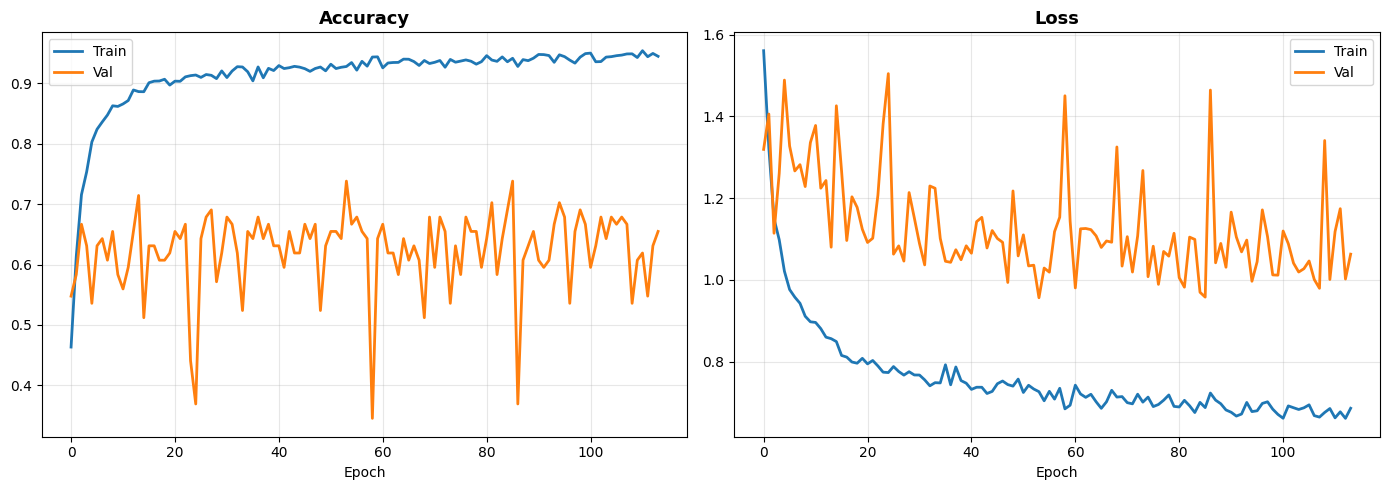


Meilleure val_accuracy : 73.81% (epoch 54)

ÉVALUATION COMPLÈTE

  Train : 97.80%
  Val   : 73.81%   (REAL)
  Test  : 78.12%   (REAL + TTA×5)

  Gap Train→Test : 19.67%
  ⚠ Overfitting significatif (>15%)


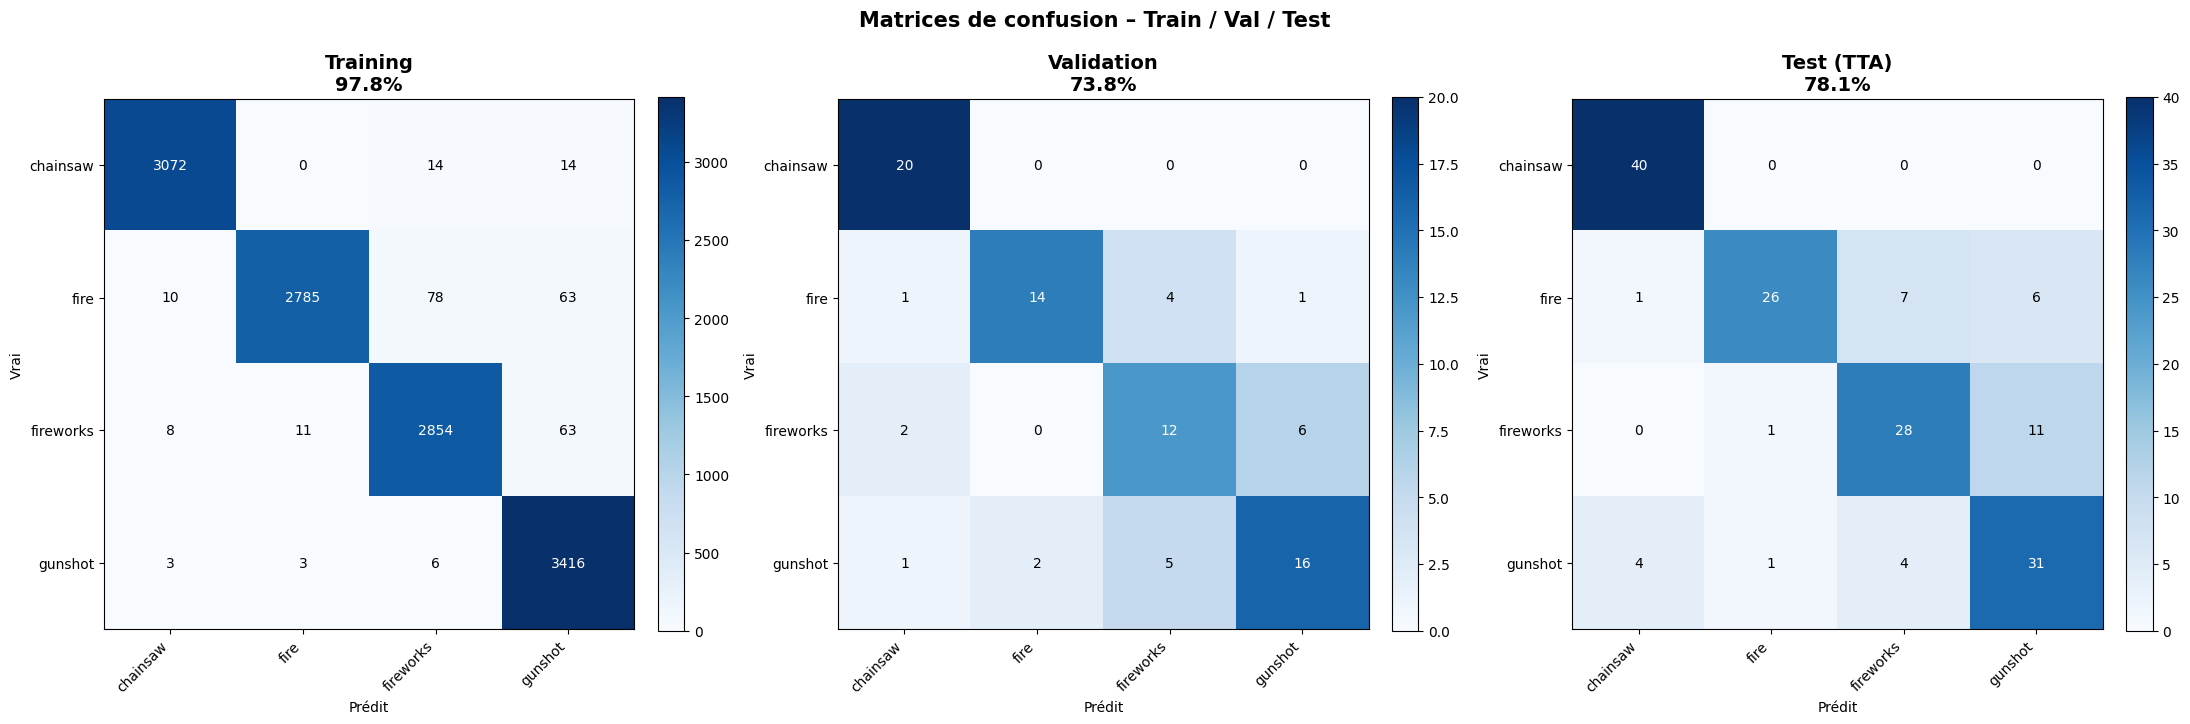


Classe           Précision     Rappel       F1    Support
------------------------------------------------------------
chainsaw             0.889      1.000    0.941         40
fire                 0.929      0.650    0.765         40
fireworks            0.718      0.700    0.709         40
gunshot              0.646      0.775    0.705         40
------------------------------------------------------------
Macro Avg            0.795      0.781    0.780        160

  Test Accuracy (TTA×5) : 78.12%


In [ ]:
dataset = Dataset()
dataset.remove_class("background")
dataset.remove_class("birds")
dataset.remove_class("handsaw")
dataset.remove_class("helicopter")

model, metrics, classnames, extractor = main_pipeline(dataset, config)